#### Installing and importing libraries

In [1]:
!pip install -U nltk
!pip install tensorflow
!pip install tensorflow_hub
!pip install torch
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.6 MB/s eta 0:00:00
  Attempting uninstall: nltk
    Found existing installation: nltk 3.9.1
    Uninstalling nltk-3.9.1:
      Successfully uninstalled nltk-3.9.1


In [2]:
import pandas as pd
import numpy as np
import nltk
import re
import torch
import tensorflow as tf
import tensorflow_hub as hub
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt

#### To check is there any GPU available or not

In [3]:
is_cuda = torch.cuda.is_available()

# If we have a GPU available, we'll set our device to GPU.
if is_cuda:
    device = torch.device("cuda")
    print("GPU is available")
else:
    device = torch.device("cpu")
    print("GPU not available, CPU used")


GPU not available, CPU used


#### Load the Telegram dataset for sentiment analysis between positive and negative reviews

In [4]:
df = pd.read_csv('df_clean.csv')
df = df.sample(frac=1).reset_index(drop=True)
df

,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,content_clean,word_count,content_tfidf,review_date
0,mau daftar aja susah. apus aja sekalian aplika...,1,0,NaN,2025-08-23 04:56:13,NaN,NaN,mau daftar saja susah apus saja sekalian aplik...,9,mau daftar susah apus sekali aplikasi kalo mau...,2025-08-23
1,makin lama makin ga jelas apk nyaa,2,0,NaN,2025-08-20 13:18:46,NaN,NaN,makin lama makin tidak jelas aplikasi nyaa,6,makin lama makin jelas aplikasi nyaa,2025-08-20
2,good APK 👍,5,0,12.0.1,2025-10-21 13:37:44,NaN,NaN,good aplikasi,2,good aplikasi,2025-10-21
3,bangle pake premium,1,0,12.4.1,2026-02-10 07:01:50,NaN,NaN,bangle pake premium,3,bangle pake premium,2026-02-10
4,apasih bug dibuka gak jelas banget,2,0,NaN,2025-12-07 05:40:55,NaN,NaN,apasih bug dibuka gak jelas banget,6,apasih bug buka gak jelas banget,2025-12-07
...,...,...,...,...,...,...,...,...,...,...,...
17597,"saya tidak mengerti, kenapa saya tidak bisa me...",1,1,NaN,2026-01-11 22:50:03,NaN,NaN,saya tidak mengerti kenapa saya tidak bisa men...,20,erti kirim pesan luar negri padahal belum beda...,2026-01-11
17598,buat developer klo ga bisa ngurus telegram mun...,1,0,12.3.1,2026-01-28 05:09:57,NaN,NaN,buat developer klo tidak bisa ngurus telegram ...,16,buat developer klo ngurus telegram mundur jaba...,2026-01-28
17599,jelek banget asli masa skrng harus berbayar?? ...,1,1,NaN,2026-03-08 16:07:48,NaN,NaN,jelek banget asli masa skrng harus berbayar ma...,17,jelek banget asli masa skrng bayar mana mau du...,2026-03-08
17600,Woy tolonglah benerin aplikasinya masa gue mau...,1,1,12.0.1,2025-09-28 11:25:38,Kami minta maaf atas kendala yang Anda alami. ...,2025-02-18 15:16:14,woy tolonglah benerin aplikasinya masa gue mau...,34,woy tolong benerin aplikasi masa gue mau login...,2025-09-28


In [5]:
df = df[['score', 'content_tfidf']]
df

,score,content_tfidf
0,1,mau daftar susah apus sekali aplikasi kalo mau...
1,2,makin lama makin jelas aplikasi nyaa
2,5,good aplikasi
3,1,bangle pake premium
4,2,apasih bug buka gak jelas banget
...,...,...
17597,1,erti kirim pesan luar negri padahal belum beda...
17598,1,buat developer klo ngurus telegram mundur jaba...
17599,1,jelek banget asli masa skrng bayar mana mau du...
17600,1,woy tolong benerin aplikasi masa gue mau login...


In [6]:
def sentiment_label(score):
    if score >= 4:
        return "positive"
    elif score == 3:
        return "neutral"
    else:
        return "negative"

df["sentiment"] = df["score"].apply(sentiment_label)

/tmp/ipykernel_1435/3668957397.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sentiment"] = df["score"].apply(sentiment_label)


In [7]:
df = df[['content_tfidf', 'sentiment']]
df

,content_tfidf,sentiment
0,mau daftar susah apus sekali aplikasi kalo mau...,negative
1,makin lama makin jelas aplikasi nyaa,negative
2,good aplikasi,positive
3,bangle pake premium,negative
4,apasih bug buka gak jelas banget,negative
...,...,...
17597,erti kirim pesan luar negri padahal belum beda...,negative
17598,buat developer klo ngurus telegram mundur jaba...,negative
17599,jelek banget asli masa skrng bayar mana mau du...,negative
17600,woy tolong benerin aplikasi masa gue mau login...,negative


#### Exploratory Data Analysis for Telegram dataset

In [8]:
class EDA():
    def get_length_dist(self,data):
        rev_len = [len(i) for i in data]
        pd.Series(rev_len).hist()
        plt.title('Number of types of comments')
        plt.xlabel('length')
        plt.ylabel('number')
        plt.show()
        print(pd.Series(rev_len).describe())
    def get_class_dist(self,df):
        df['sentiment'].replace({1:'positive',0:'negative'}).value_counts().plot(kind='bar',figsize=(7,4))
        plt.title('Number of types')
        plt.xlabel('Comment_type')
        plt.ylabel('number')
        plt.show()

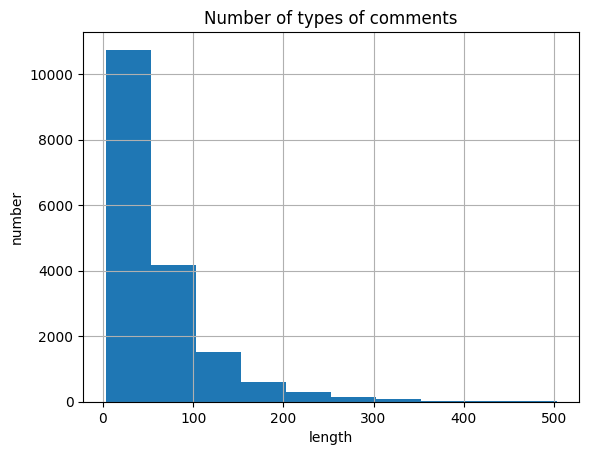

count    17602.000000
mean        59.137200
std         56.869612
min          3.000000
25%         22.000000
50%         41.000000
75%         75.000000
max        503.000000
dtype: float64


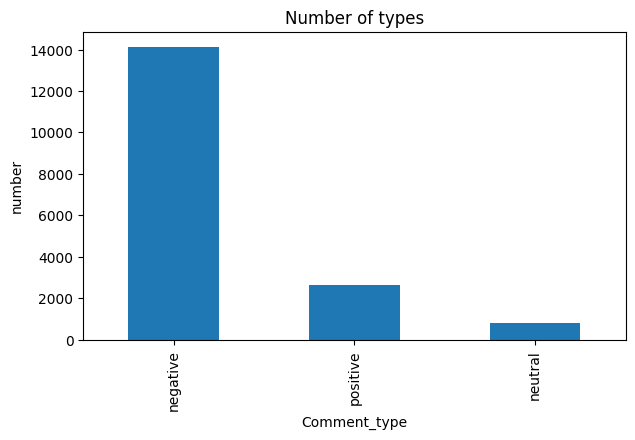

In [9]:
eda = EDA()
eda.get_length_dist(df['content_tfidf'])
eda.get_class_dist(df)

#### Split x=feature, y=target

In [11]:
x = df['content_tfidf']
y = df['sentiment']

In [12]:
from sklearn.preprocessing import LabelEncoder
label_encode = LabelEncoder()
Y = label_encode.fit_transform(df['sentiment'])
Y

array([0, 0, 2, ..., 0, 0, 0])

In [13]:
y

,sentiment
0,negative
1,negative
2,positive
3,negative
4,negative
...,...
17597,negative
17598,negative
17599,negative
17600,negative


### Note: 0 represent negative comments and 1 represent positive comments

### Split the dataset into training and testing sets


In [14]:
xtrain, xtest, ytrain, ytest = train_test_split(x, Y, test_size=0.2, random_state=42)

### Create a vocabulary

In [15]:
# Create a vocabulary
from collections import Counter
word_counts = Counter(' '.join(xtrain).split())

### Display each word in the vocabulary along with its count


In [16]:
for word, count in word_counts.items():
    print(f"{word}: {count}")

banget: 1598
semua: 433
bayar: 5113
verifikasi: 452
akun: 2073
mending: 147
kaya: 283
dulu: 1909
simpel: 18
banyak: 553
org: 80
aneh: 544
ewh: 1
tukang: 3
palak: 4
uang: 159
aplikasi: 3755
paling: 62
buruk: 189
dapat: 71
kode: 1444
telepon: 73
uninstal: 59
karna: 176
premium: 3340
update: 304
status: 73
apa: 1562
dh: 40
hiii: 1
makin: 669
jelek: 483
baru: 1299
download: 608
lg: 73
weeuuuuuyyy: 1
nomer: 216
aku: 814
blok: 26
dlu: 324
eror: 93
nga: 31
udah: 1169
paket: 34
tetep: 156
lelet: 25
kalo: 560
unduh: 55
video: 165
foto: 67
ngirim: 82
pdf: 6
percumah: 1
sangat: 702
dsarankan: 1
skrng: 185
mau: 2789
login: 3056
parah: 177
emang: 117
gak: 1543
kek: 131
gtu: 20
tinggl: 1
beres: 14
gratis: 388
sekarang: 1720
asa: 115
suka: 270
ngestuck: 6
klo: 174
nonton: 75
sms: 723
ideal: 1
kamu: 30
miskin: 56
knp: 239
pas: 574
msuk: 37
pesan: 197
free: 135
gmn: 68
jelasin: 2
punya: 189
sya: 58
minta: 297
kali: 390
tele: 957
dah: 269
masuk: 1829
kalau: 389
memang: 44
at: 15
least: 1
kembali: 111
ku

In [17]:
vocab = [word for word, count in word_counts.most_common()]
vocab

['bayar',
 'aplikasi',
 'telegram',
 'premium',
 'login',
 'mau',
 'akun',
 'dulu',
 'masuk',
 'sekarang',
 'banget',
 'daftar',
 'apa',
 'gak',
 'kode',
 'buat',
 'baru',
 'tiba',
 'udah',
 'padahal',
 'malah',
 'suruh',
 'tele',
 'jadi',
 'masa',
 'aku',
 'susah',
 'baik',
 'bagus',
 'sms',
 'sangat',
 'pake',
 'lama',
 'kirim',
 'makin',
 'guna',
 'email',
 'nomor',
 'download',
 'pas',
 'bikin',
 'kalo',
 'banyak',
 'aneh',
 'sama',
 'orang',
 'jelek',
 'jelas',
 'log',
 'verifikasi',
 'gabisa',
 'semua',
 'terus',
 'pakai',
 'gimana',
 'buka',
 'ribet',
 'bintang',
 'in',
 'kali',
 'no',
 'kalau',
 'gratis',
 'jangan',
 'kasih',
 'hapus',
 'sekali',
 'hp',
 'gin',
 'coba',
 'otp',
 'dlu',
 'to',
 'sendiri',
 'sulit',
 'update',
 'kecewa',
 'fitur',
 'minta',
 'beli',
 'prem',
 'i',
 'gw',
 'kaya',
 'story',
 'ni',
 'lebih',
 'mana',
 'bantu',
 'suka',
 'dah',
 'muncul',
 'gua',
 'kan',
 'kikir',
 'knp',
 'mohon',
 'ganti',
 'langsung',
 'doang',
 'kayak',
 'tipu',
 'langgan',
 'sk

### Classification with various classifiers
#### 1. Linear SVM
#### 2. Logistic Regression (LR)
#### 3. Naive Bayes
#### 4. XGBoost
#### 5. Random Forest

In [18]:
#Import libraries
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from timeit import default_timer as timer

#### Initialize classifiers

In [19]:
svm_classifier = LinearSVC()
logistic_regression = LogisticRegression(max_iter=1000)
nb_classifier = MultinomialNB()
xgboost_classifier = XGBClassifier()
random_forest_classifier = RandomForestClassifier(n_estimators=100, max_depth=3, max_features='sqrt', min_samples_leaf=4, bootstrap=True, n_jobs=-1, random_state=0)

In [31]:
def evaluate_model(model, xtest, ytest):
    # Make predictions using the model
    y_pred = model.predict(xtest)

    # Calculate accuracy
    accuracy = accuracy_score(ytest, y_pred)
    # Calculate precision
    precision = precision_score(ytest, y_pred, average='weighted')
    # Calculate recall
    recall = recall_score(ytest, y_pred, average='weighted')
    # Calculate f1 score
    f1 = f1_score(ytest, y_pred, average='weighted')
    # Generate a classification report and confusion matrix
    report = classification_report(ytest, y_pred)
    cm = confusion_matrix(ytest, y_pred)
    return y_pred, accuracy, precision, recall, f1, report, cm

In [21]:
# Define batch size
batch_size = 1000

## 1. TF-IDF

#### TF-IDF Vectorization


In [22]:
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

##### Process the data in smaller batches for training data


In [26]:
start = timer()
# Fit and transform the entire xtrain data at once
tfidf_vectorizer_xtrain = tfidf_vectorizer.fit_transform(xtrain).toarray()
print('Required time for embedding TFIDF with train data:- ', timer() - start)

Required time for embedding TFIDF with train data:-  2.0498112150000907


##### Repeat the same process for test data


In [27]:
start = timer()
# Transform the entire xtest data using the fitted vectorizer
tfidf_vectorizer_xtest = tfidf_vectorizer.transform(xtest).toarray()
print('Required time for embedding TFIDF with test data:- ', timer() - start)

Required time for embedding TFIDF with test data:-  0.635639635000075


#### Fit classifiers

In [28]:
start = timer()
svm_tfidf = svm_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Linear SVM classifiers:- ', timer() - start)
start = timer()
lr_tfidf = logistic_regression.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Logistic Regression classifiers:- ', timer() - start)
start = timer()
nb_tfidf = nb_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training Naive Bayes classifiers:- ', timer() - start)
start = timer()
xgboost_tfidf = xgboost_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training XGBoost classifiers:- ', timer() - start)
start = timer()
rfc_tfidf = random_forest_classifier.fit(tfidf_vectorizer_xtrain, ytrain)
print('Required time for training all five classifiers:- ', timer() - start)

Required time for training Linear SVM classifiers:-  1.8515425370000003
Required time for training Logistic Regression classifiers:-  32.73981113299999
Required time for training Naive Bayes classifiers:-  0.2717524570000478
Required time for training XGBoost classifiers:-  62.11324415399997
Required time for training all five classifiers:-  6.5935294399999975


#### Make predictions

### Linear SVM

In [32]:
start = timer()
y_pred_svm, accuracy_svm, precision_svm, recall_svm, f1_svm, report_svm, confusion_matrix_svm = evaluate_model(svm_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for SVM prediction:- ', timer() - start)

Required time for SVM prediction:-  0.0666008900000179


#### Print actual vs. predicted results for LinearSVM

In [33]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm[:15]):
    print(f"Actual: {actual}, SVM Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, SVM Predicted: 0

Actual: 2, SVM Predicted: 2

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 0, SVM Predicted: 0

Actual: 2, SVM Predicted: 0



In [34]:
print(f"LinearSVM Accuracy: {accuracy_svm:.2f}")
print(f"LinearSVM Precision: {precision_svm:.2f}")
print(f"LinearSVM Recall: {recall_svm:.2f}")
print(f"LinearSVM F1 score: {f1_svm:.2f}")
print("Classification Report:")
print(report_svm)
print("Confusion Matrix")
print(confusion_matrix_svm)

LinearSVM Accuracy: 0.87
LinearSVM Precision: 0.84
LinearSVM Recall: 0.87
LinearSVM F1 score: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.97      0.93      2820
           1       0.33      0.02      0.04       157
           2       0.76      0.57      0.65       544

    accuracy                           0.87      3521
   macro avg       0.66      0.52      0.54      3521
weighted avg       0.84      0.87      0.84      3521

Confusion Matrix
[[2740    4   76]
 [ 131    3   23]
 [ 232    2  310]]


### Logistic Regression

In [35]:
start = timer()
y_pred_lr, accuracy_lr, precision_lr, recall_lr, f1_lr, report_lr, cm_lr = evaluate_model(lr_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Logistic Regression prediction:- ', timer() - start)

Required time for Logistic Regression prediction:-  0.07099370500009172


#### Print actual vs. predicted results for Logistic Regression


In [36]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 2

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 0, Logistic Regression Predicted: 0

Actual: 2, Logistic Regression Predicted: 0



In [37]:
print(f"Logistic Regression Accuracy: {accuracy_lr:.2f}")
print(f"Logistic Regression Precision: {precision_lr:.2f}")
print(f"Logistic Regression Recall: {recall_lr:.2f}")
print(f"Logistic Regression F1 score: {f1_lr:.2f}")
print("Classification Report:")
print(report_lr)
print("Confusion Matrix")
print(cm_lr)

Logistic Regression Accuracy: 0.87
Logistic Regression Precision: 0.85
Logistic Regression Recall: 0.87
Logistic Regression F1 score: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2820
           1       0.50      0.01      0.01       157
           2       0.83      0.55      0.67       544

    accuracy                           0.87      3521
   macro avg       0.74      0.51      0.54      3521
weighted avg       0.85      0.87      0.85      3521

Confusion Matrix
[[2775    0   45]
 [ 141    1   15]
 [ 242    1  301]]


### Naive bayes

In [38]:
start = timer()
y_pred_nb, accuracy_nb, precision_nb, recall_nb, f1_nb, report_nb, cm_nb = evaluate_model(nb_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Naive Bayes prediction:- ', timer() - start)

Required time for Naive Bayes prediction:-  0.06594777899999826


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#### Print actual vs. predicted results for Naive bayes


In [39]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_nb[:15]):
    print(f"Actual: {actual}, Naive bayes Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 2

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 0, Naive bayes Predicted: 0

Actual: 2, Naive bayes Predicted: 0



In [40]:
print(f"Naive bayes Accuracy: {accuracy_nb:.2f}")
print(f"Naive bayes Precision: {precision_nb:.2f}")
print(f"Naive bayes Recall: {recall_nb:.2f}")
print(f"Naive bayes F1 score: {f1_nb:.2f}")
print("Classification Report:")
print(report_nb)
print("Confusion Matrix:")
print(cm_nb)

Naive bayes Accuracy: 0.84
Naive bayes Precision: 0.81
Naive bayes Recall: 0.84
Naive bayes F1 score: 0.80
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.99      0.91      2820
           1       0.00      0.00      0.00       157
           2       0.84      0.33      0.47       544

    accuracy                           0.84      3521
   macro avg       0.56      0.44      0.46      3521
weighted avg       0.81      0.84      0.80      3521

Confusion Matrix:
[[2794    0   26]
 [ 149    0    8]
 [ 366    0  178]]


### XGBoost Classifier

In [41]:
start = timer()
y_pred_xgboost, accuracy_xgboost, precision_xgboost, recall_xgboost, f1_xgboost, report_xgboost, cm_xgboost = evaluate_model(xgboost_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for XGBoost classifier prediction:- ', timer() - start)

Required time for XGBoost classifier prediction:-  0.2081730370000514


#### Print actual vs. predicted results for XGBoost classifier


In [42]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost[:15]):
    print(f"Actual: {actual}, XGBoost Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 0, XGBoost Predicted: 0

Actual: 2, XGBoost Predicted: 0



In [43]:
print(f"XGBoost Accuracy: {accuracy_xgboost:.2f}")
print(f"XGBoost Precision: {precision_xgboost:.2f}")
print(f"XGBoost Recall: {recall_xgboost:.2f}")
print(f"XGBoost F1 score: {f1_xgboost:.2f}")
print("Classification Report:")
print(report_xgboost)
print("Confusion Matrix:")
print(cm_xgboost)

XGBoost Accuracy: 0.87
XGBoost Precision: 0.83
XGBoost Recall: 0.87
XGBoost F1 score: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.98      0.92      2820
           1       0.20      0.01      0.01       157
           2       0.82      0.52      0.64       544

    accuracy                           0.87      3521
   macro avg       0.63      0.50      0.52      3521
weighted avg       0.83      0.87      0.84      3521

Confusion Matrix:
[[2766    2   52]
 [ 144    1   12]
 [ 258    2  284]]


### Random Forest Classifier

In [44]:
start = timer()
y_pred_rfc, accuracy_rfc, precision_rfc, recall_rfc, f1_rfc, report_rfc, cm_rfc = evaluate_model(rfc_tfidf, tfidf_vectorizer_xtest, ytest)
print('Required time for Random Forest classifier prediction:- ', timer() - start)

Required time for Random Forest classifier prediction:-  0.09634557499998664


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#### Print actual vs. predicted results for Random Forest classifier

In [45]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc[:15]):
    print(f"Actual: {actual}, Random Forest Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 0, Random Forest Predicted: 0

Actual: 2, Random Forest Predicted: 0



In [46]:
print(f"Random Forest Accuracy: {accuracy_rfc:.2f}")
print(f"Random Forest Precision: {precision_rfc:.2f}")
print(f"Random Forest Recall: {recall_rfc:.2f}")
print(f"Random Forest F1 score: {f1_rfc:.2f}")
print("Classification Report:")
print(report_rfc)
print("Confusion Matrix:")
print(cm_rfc)

Random Forest Accuracy: 0.80
Random Forest Precision: 0.64
Random Forest Recall: 0.80
Random Forest F1 score: 0.71
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2820
           1       0.00      0.00      0.00       157
           2       0.00      0.00      0.00       544

    accuracy                           0.80      3521
   macro avg       0.27      0.33      0.30      3521
weighted avg       0.64      0.80      0.71      3521

Confusion Matrix:
[[2820    0    0]
 [ 157    0    0]
 [ 544    0    0]]


#### Display all five models accuracy

In [47]:
model_names = ['LinearSVM', 'LogisticRegression', 'NaiveBayes', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm, accuracy_lr, accuracy_nb, accuracy_xgboost, accuracy_rfc]

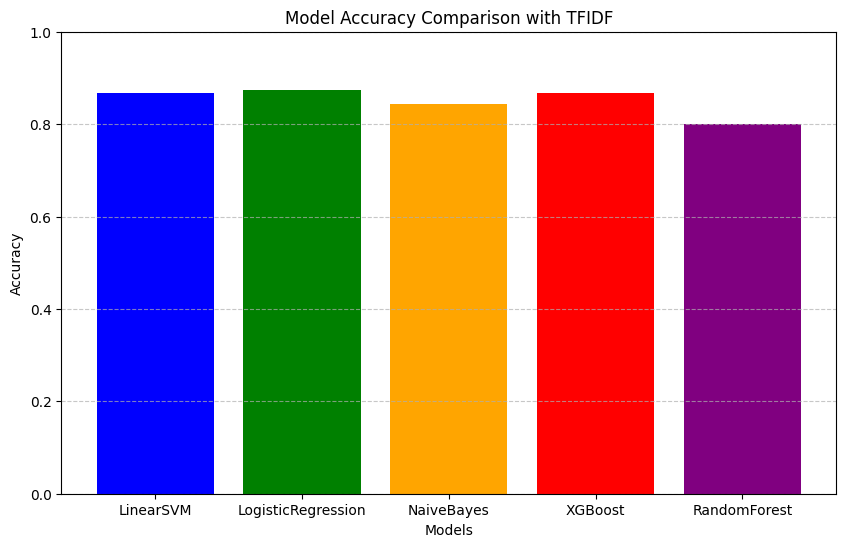

In [48]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['blue', 'green', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with TFIDF")
plt.ylim(0.0, 1.0)  # Set the y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 2. Universal Sentence Encoder (USE)
#### 1. Linear SVM
#### 2. Logistic Regression
#### 3. XGBoost classifier
#### 4. Random Forest classifier

#### Load the Universal Sentence Encoder model, and embed this model

In [49]:
start = timer()
embed = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")
print('Required time for upload USE from tensorflow hub:- ', timer() - start)

Required time for upload USE from tensorflow hub:-  54.528078871999924


In [50]:
xtrain_use = []
xtest_use = []

In [51]:
start = timer()
for i in range(0, len(xtrain), batch_size):
    batch_X_train = xtrain[i:i + batch_size]
    batch_X_train_use = np.array(embed(batch_X_train))
    xtrain_use.extend(batch_X_train_use)
print('Required time for embedding xtrain with USE:- ', timer() - start)

Required time for embedding xtrain with USE:-  2.440777924000031


In [52]:
start = timer()
for i in range(0, len(xtest), batch_size):
    batch_X_test = xtest[i:i + batch_size]
    batch_X_test_use = np.array(embed(batch_X_test))
    xtest_use.extend(batch_X_test_use)
print('Required time for embedding xtest with USE:- ', timer() - start)

Required time for embedding xtest with USE:-  0.9593437510000058


#### Fit classifiers

In [53]:
start = timer()
svm_use = svm_classifier.fit(xtrain_use, ytrain)
print('Required time for training Linear SVM classifier:- ', timer() - start)
start = timer()
lr_use = logistic_regression.fit(xtrain_use, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)
start = timer()
xgboost_use = xgboost_classifier.fit(xtrain_use, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start)
start = timer()
rfc_use = random_forest_classifier.fit(xtrain_use, ytrain)
print('Required time for training all Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM classifier:-  11.929983212000025
Required time for training Logistic Regression:-  6.372132297999997
Required time for training XGBoost classifier:-  65.57525921600018
Required time for training all Random Forest classifier:-  12.284034961000089


#### Make predictions

### Linear SVM

In [54]:
start = timer()
y_pred_svm_use, accuracy_svm_use, precision_svm_use, recall_svm_use, f1_svm_use, report_svm_use, cm_svm_use = evaluate_model(svm_use, xtest_use, ytest)
print('Required time for Linear SVM prediction with USE :- ', timer() - start)

Required time for Linear SVM prediction with USE :-  0.0345962490000602


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#### Print actual vs. predicted results for LinearSVM with USE

In [55]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_use[:15]):
    print(f"Actual: {actual}, SVM with USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 2

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 0, SVM with USE embedding Predicted: 0

Actual: 2, SVM with USE embedding Predicted: 0



In [56]:
print(f"LinearSVM (USE) Accuracy: {accuracy_svm_use:.2f}")
print(f"LinearSVM (USE) Precision: {precision_svm_use:.2f}")
print(f"LinearSVM (USE) Recall: {recall_svm_use:.2f}")
print(f"LinearSVM (USE) F1 score: {f1_svm_use:.2f}")
print("Classification Report:")
print(report_svm_use)
print("Confusion Matrix")
print(cm_svm_use)

LinearSVM (USE) Accuracy: 0.85
LinearSVM (USE) Precision: 0.80
LinearSVM (USE) Recall: 0.85
LinearSVM (USE) F1 score: 0.81
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.91      2820
           1       0.00      0.00      0.00       157
           2       0.75      0.40      0.52       544

    accuracy                           0.85      3521
   macro avg       0.54      0.46      0.48      3521
weighted avg       0.80      0.85      0.81      3521

Confusion Matrix
[[2762    0   58]
 [ 143    0   14]
 [ 325    0  219]]


### Logitic Regression

In [57]:
start = timer()
y_pred_lr_use, accuracy_lr_use, precision_lr_use, recall_lr_use, f1_lr_use, report_lr_use, cm_lr_use = evaluate_model(lr_use, xtest_use, ytest)
print('Required time for LR prediction with USE :- ', timer() - start)

Required time for LR prediction with USE :-  0.03793710800005101


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#### Print actual vs. predicted results for Logistic Regression with USE

In [58]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_use[:15]):
    print(f"Actual: {actual}, Logistic Regression Predicted with USE: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 2

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 2

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 0, Logistic Regression Predicted with USE: 0

Actual: 2, Logistic Regression Predicted with USE: 0



In [ ]:
print(f"Logistic Regression (USE) Accuracy: {accuracy_lr_use:.2f}")
print(f"Logistic Regression (USE) Precision: {precision_lr_use:.2f}")
print(f"Logistic Regression (USE) Recall: {recall_lr_use:.2f}")
print(f"Logistic Regression (USE) F1 score: {f1_lr_use:.2f}")
print("Classification Report:")
print(report_lr_use)
print("Confusion Matrix")
print(cm_lr_use)

Logistic Regression (USE) Accuracy: 0.84
Logistic Regression (USE) Precision: 0.84
Logistic Regression (USE) Recall: 0.84
Logistic Regression (USE) F1 score: 0.84
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      4941
           1       0.84      0.84      0.84      5059

    accuracy                           0.84     10000
   macro avg       0.84      0.84      0.84     10000
weighted avg       0.84      0.84      0.84     10000

Confusion Matrix
[[4125  816]
 [ 786 4273]]


### XGBoost Classifier

In [59]:
start = timer()
y_pred_xgboost_use, accuracy_xgboost_use, precision_xgboost_use, recall_xgboost_use, f1_xgboost_use, report_xgboost_use, cm_xgboost_use = evaluate_model(xgboost_use, xtest_use, ytest)
print('Required time for XGBoost classifier prediction with USE:- ', timer() - start)

Required time for XGBoost classifier prediction with USE:-  0.08226500699993267


#### Print actual vs. predicted results for XGBooost classifier with USE

In [60]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgboost_use[:15]):
    print(f"Actual: {actual}, XGBoost with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 2

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 0, XGBoost with USE Predicted: 0

Actual: 2, XGBoost with USE Predicted: 0



In [61]:
print(f"XGBoost (USE) Accuracy: {accuracy_xgboost_use:.2f}")
print(f"XGBoost (USE) Precision: {precision_xgboost_use:.2f}")
print(f"XGBoost (USE) Recall: {recall_xgboost_use:.2f}")
print(f"XGBoost (USE) F1 score: {f1_xgboost_use:.2f}")
print("Classification Report:")
print(report_xgboost_use)
print("Confusion Matrix:")
print(cm_xgboost_use)

XGBoost (USE) Accuracy: 0.85
XGBoost (USE) Precision: 0.82
XGBoost (USE) Recall: 0.85
XGBoost (USE) F1 score: 0.82
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92      2820
           1       0.17      0.01      0.01       157
           2       0.80      0.41      0.54       544

    accuracy                           0.85      3521
   macro avg       0.61      0.47      0.49      3521
weighted avg       0.82      0.85      0.82      3521

Confusion Matrix:
[[2774    5   41]
 [ 141    1   15]
 [ 323    0  221]]


### Random Forest Classifier

In [62]:
start = timer()
y_pred_rfc_use, accuracy_rfc_use, precision_rfc_use, recall_rfc_use, f1_rfc_use, report_rfc_use, cm_rfc_use = evaluate_model(rfc_use, xtest_use, ytest)
print('Required time for Random Forest classifier with USE prediction:- ', timer() - start)

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Required time for Random Forest classifier with USE prediction:-  0.07486559600010878


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


#### Print actual vs. predicted results for Random Forest classifier with USE

In [63]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_use[:15]):
    print(f"Actual: {actual}, Random Forest with USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 0, Random Forest with USE Predicted: 0

Actual: 2, Random Forest with USE Predicted: 0



In [64]:
print(f"Random Forest (USE) Accuracy: {accuracy_rfc_use:.2f}")
print(f"Random Forest (USE) Precision: {precision_rfc_use:.2f}")
print(f"Random Forest (USE) Recall: {recall_rfc_use:.2f}")
print(f"Random Forest (USE) F1 score: {f1_rfc_use:.2f}")
print("Classification Report:")
print(report_rfc_use)
print("Confusion Matrix:")
print(cm_rfc_use)

Random Forest (USE) Accuracy: 0.81
Random Forest (USE) Precision: 0.79
Random Forest (USE) Recall: 0.81
Random Forest (USE) F1 score: 0.74
Classification Report:
              precision    recall  f1-score   support

           0       0.81      1.00      0.90      2820
           1       0.00      0.00      0.00       157
           2       0.92      0.09      0.16       544

    accuracy                           0.81      3521
   macro avg       0.58      0.36      0.35      3521
weighted avg       0.79      0.81      0.74      3521

Confusion Matrix:
[[2818    0    2]
 [ 155    0    2]
 [ 495    0   49]]


#### Display all four models accuracy
##### (--Note: Naive bayes (MultinomialNB) model not used with USE embedding because it not able to resolve the issue of negative values)

In [65]:
model_names = ['LinearSVM', 'LogisticRegression', 'XGBoost', 'RandomForest']
model_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]

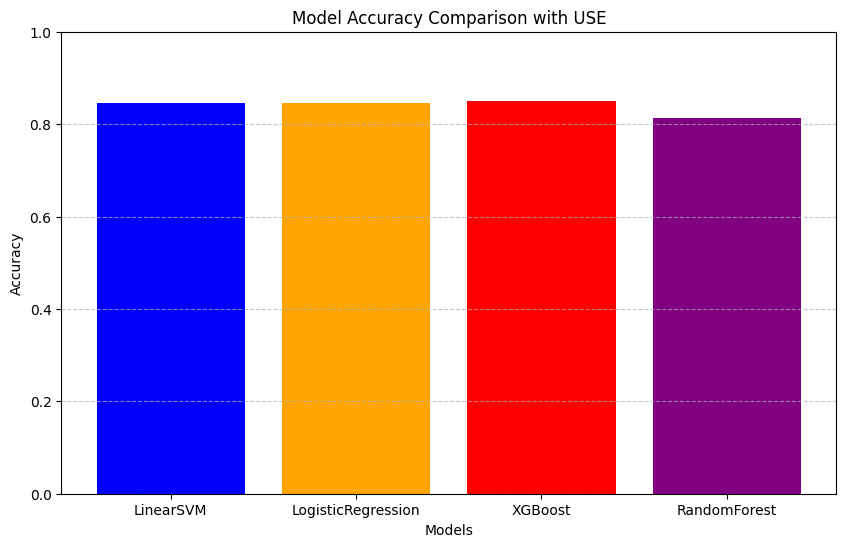

In [66]:
plt.figure(figsize=(10, 6))
plt.bar(model_names, model_accuracies, color=['blue', 'orange', 'red', 'purple'])
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison with USE")
plt.ylim(0.0, 1.0)  # Set the y-axis limits
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## 3. TF-IDF + Universal Sentence Encoder (USE)
#### 1. Linear SVM
#### 2. Logistic Regression
#### 3. XGBoost classifier
#### 4. Random Forest classifier

#### Combine TF-IDF and Universal Sentence Encoder embeddings


In [67]:
xtrain_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtrain, xtrain_use], axis=1)
xtest_tfidf_use_combined = tf.concat([tfidf_vectorizer_xtest, xtest_use], axis=1)

#### Fit classifiers

In [68]:
start = timer()
svm_tfidf_use = svm_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Linear SVM:- ', timer() - start)
start = timer()
lr_tfidf_use = logistic_regression.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Logistic Regression:- ', timer() - start)
start = timer()
xgboost_tfidf_use = xgboost_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training XGBoost classifier:- ', timer() - start)
start = timer()
rfc_tfidf_use = random_forest_classifier.fit(xtrain_tfidf_use_combined, ytrain)
print('Required time for training Random Forest classifier:- ', timer() - start)

Required time for training Linear SVM:-  12.795545152999921
Required time for training Logistic Regression:-  28.86714577099997
Required time for training XGBoost classifier:-  121.74150757100006
Required time for training Random Forest classifier:-  11.729392961999793


#### Make predictions

### Linear SVM

In [69]:
start = timer()
y_pred_svm_tfidf_use, accuracy_svm_tfidf_use, precision_svm_tfidf_use, recall_svm_tfidf_use, f1_svm_tfidf_use, report_svm_tfidf_use, cm_svm_tfidf_use = evaluate_model(svm_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Linear SVM prediction with TFIDF+USE :- ', timer() - start)

Required time for Linear SVM prediction with TFIDF+USE :-  0.1681445540000368


#### Print actual vs. predicted results for Linear SVM with TFIDF + USE

In [70]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_svm_tfidf_use[:15]):
    print(f"Actual: {actual}, SVM with TFIDF+USE Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 2

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 0, SVM with TFIDF+USE Predicted: 0

Actual: 2, SVM with TFIDF+USE Predicted: 0



In [71]:
print(f"LinearSVM (TFIDF+USE) Accuracy: {accuracy_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Precision: {precision_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) Recall: {recall_svm_tfidf_use:.2f}")
print(f"LinearSVM (TFIDF+USE) F1 score: {f1_svm_tfidf_use:.2f}")
print("Classification Report:")
print(report_svm_tfidf_use)
print("Confusion Matrix")
print(cm_svm_tfidf_use)

LinearSVM (TFIDF+USE) Accuracy: 0.87
LinearSVM (TFIDF+USE) Precision: 0.84
LinearSVM (TFIDF+USE) Recall: 0.87
LinearSVM (TFIDF+USE) F1 score: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      2820
           1       0.40      0.03      0.05       157
           2       0.75      0.60      0.66       544

    accuracy                           0.87      3521
   macro avg       0.68      0.53      0.55      3521
weighted avg       0.84      0.87      0.85      3521

Confusion Matrix
[[2732    5   83]
 [ 126    4   27]
 [ 219    1  324]]


### Logistic Regression

In [72]:
start = timer()
y_pred_lr_tfidf_use, accuracy_lr_tfidf_use, precision_lr_tfidf_use, recall_lr_tfidf_use, f1_lr_tfidf_use, report_lr_tfidf_use, cm_lr_tfidf_use = evaluate_model(lr_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Logistic Regression prediction with TFIDF+USE :- ', timer() - start)

Required time for Logistic Regression prediction with TFIDF+USE :-  0.1351705540000694


#### Print actual vs. predicted results for Logistic Regression with TFIDF + USE

In [73]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_lr_tfidf_use[:15]):
    print(f"Actual: {actual}, LR with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 2

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 0, LR with TFIDF+USE embedding Predicted: 0

Actual: 2, LR with TFIDF+USE embedding Predicted: 0



In [74]:
print(f"Logistic Regression (TFIDF+USE) Accuracy: {accuracy_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Precision: {precision_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) Recall: {recall_lr_tfidf_use:.2f}")
print(f"Logistic Regression (TFIDF+USE) F1 score: {f1_lr_tfidf_use:.2f}")
print("Classification Report:")
print(report_lr_tfidf_use)
print("Confusion Matrix")
print(cm_lr_tfidf_use)

Logistic Regression (TFIDF+USE) Accuracy: 0.87
Logistic Regression (TFIDF+USE) Precision: 0.84
Logistic Regression (TFIDF+USE) Recall: 0.87
Logistic Regression (TFIDF+USE) F1 score: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.98      0.93      2820
           1       0.25      0.01      0.01       157
           2       0.80      0.58      0.67       544

    accuracy                           0.87      3521
   macro avg       0.64      0.52      0.54      3521
weighted avg       0.84      0.87      0.85      3521

Confusion Matrix
[[2759    2   59]
 [ 135    1   21]
 [ 226    1  317]]


### XGBoost Classifier

In [75]:
start = timer()
y_pred_xgb_tfidf_use, accuracy_xgb_tfidf_use, precision_xgb_tfidf_use, recall_xgb_tfidf_use, f1_xgb_tfidf_use, report_xgb_tfidf_use, cm_xgb_tfidf_use = evaluate_model(xgboost_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for XGBoost prediction with TFIDF+USE :- ', timer() - start)

Required time for XGBoost prediction with TFIDF+USE :-  0.9064628619998985


#### Print actual vs. predicted results for XGBoost with TFIDF + USE

In [76]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_xgb_tfidf_use[:15]):
    print(f"Actual: {actual}, XGBoost with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 2

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 0, XGBoost with TFIDF+USE embedding Predicted: 0

Actual: 2, XGBoost with TFIDF+USE embedding Predicted: 0



In [77]:
print(f"XGBoost (TFIDF+USE) Accuracy: {accuracy_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Precision: {precision_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) Recall: {recall_xgb_tfidf_use:.2f}")
print(f"XGBoost (TFIDF+USE) F1 score: {f1_xgb_tfidf_use:.2f}")
print("Classification Report:")
print(report_xgb_tfidf_use)
print("Confusion Matrix:")
print(cm_xgb_tfidf_use)

XGBoost (TFIDF+USE) Accuracy: 0.86
XGBoost (TFIDF+USE) Precision: 0.83
XGBoost (TFIDF+USE) Recall: 0.86
XGBoost (TFIDF+USE) F1 score: 0.83
Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      2820
           1       0.25      0.01      0.02       157
           2       0.76      0.52      0.62       544

    accuracy                           0.86      3521
   macro avg       0.63      0.50      0.52      3521
weighted avg       0.83      0.86      0.83      3521

Confusion Matrix:
[[2744    5   71]
 [ 138    2   17]
 [ 260    1  283]]


### Random Forest classifier

In [78]:
start = timer()
y_pred_rfc_tfidf_use, accuracy_rfc_tfidf_use, precision_rfc_tfidf_use, recall_rfc_tfidf_use, f1_rfc_tfidf_use, report_rfc_tfidf_use, cm_rfc_tfidf_use = evaluate_model(rfc_tfidf_use, xtest_tfidf_use_combined, ytest)
print('Required time for Random Forest prediction with TFIDF+USE :- ', timer() - start)

Required time for Random Forest prediction with TFIDF+USE :-  0.14051113999994413


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#### Print actual vs. predicted results for Random Forest with TFIDF + USE

In [79]:
print('0 = negative, 1 = positive')
for actual, predicted in zip(ytest[:15], y_pred_rfc_tfidf_use[:15]):
    print(f"Actual: {actual}, RFC with TFIDF+USE embedding Predicted: {predicted}")
    print()

0 = negative, 1 = positive
Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 0, RFC with TFIDF+USE embedding Predicted: 0

Actual: 2, RFC with TFIDF+USE embedding Predicted: 0



In [80]:
print(f"Random Forest (TFIDF+USE) Accuracy: {accuracy_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Precision: {precision_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) Recall: {recall_rfc_tfidf_use:.2f}")
print(f"Random Forest (TFIDF+USE) F1 score: {f1_rfc_tfidf_use:.2f}")
print("Classification Report:")
print(report_rfc_tfidf_use)
print("Confusion Matrix:")
print(cm_rfc_tfidf_use)

Random Forest (TFIDF+USE) Accuracy: 0.80
Random Forest (TFIDF+USE) Precision: 0.80
Random Forest (TFIDF+USE) Recall: 0.80
Random Forest (TFIDF+USE) F1 score: 0.72
Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89      2820
           1       0.00      0.00      0.00       157
           2       1.00      0.02      0.04       544

    accuracy                           0.80      3521
   macro avg       0.60      0.34      0.31      3521
weighted avg       0.80      0.80      0.72      3521

Confusion Matrix:
[[2820    0    0]
 [ 157    0    0]
 [ 532    0   12]]


### Visualization

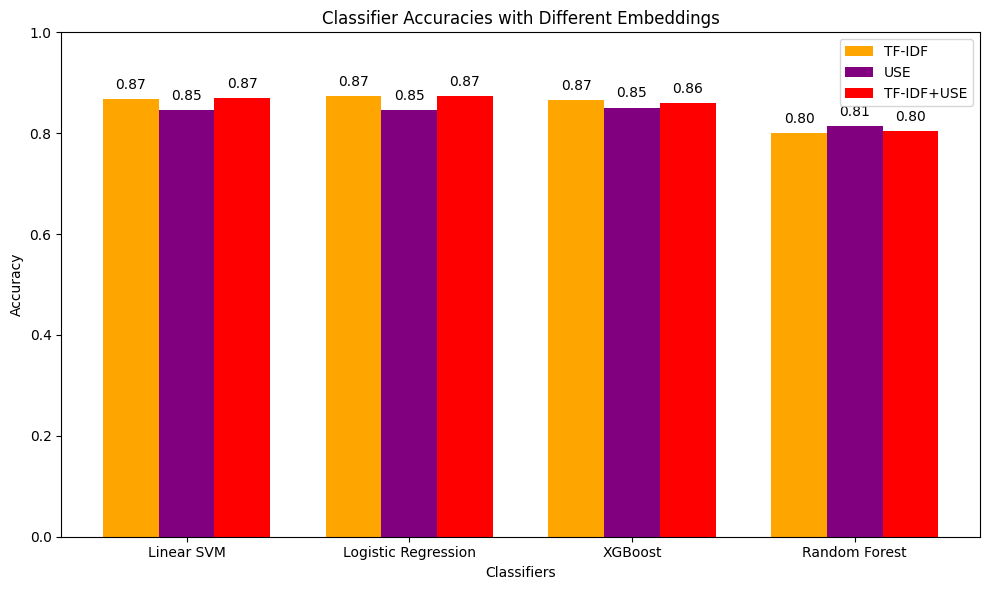

In [81]:
# Define the classifiers and their corresponding accuracies
classifiers = ["Linear SVM", "Logistic Regression", "XGBoost", "Random Forest"]
tfidf_accuracies = [accuracy_svm, accuracy_lr, accuracy_xgboost, accuracy_rfc]  # Replace with actual accuracy values
use_accuracies = [accuracy_svm_use, accuracy_lr_use, accuracy_xgboost_use, accuracy_rfc_use]  # Replace with actual accuracy values
tfidf_use_accuracies = [accuracy_svm_tfidf_use, accuracy_lr_tfidf_use, accuracy_xgb_tfidf_use, accuracy_rfc_tfidf_use]  # Replace with actual accuracy values

# Create an index for the x-axis
x = np.arange(len(classifiers))

# Set the width of the bars
bar_width = 0.25

# Create a grouped bar chart
plt.figure(figsize=(10, 6))
plt.bar(x - bar_width, tfidf_accuracies, bar_width, label='TF-IDF', color='orange')
plt.bar(x, use_accuracies, bar_width, label='USE', color='purple')
plt.bar(x + bar_width, tfidf_use_accuracies, bar_width, label='TF-IDF+USE', color='red')

# Set labels, title, and legend
plt.xlabel('Classifiers')
plt.ylabel('Accuracy')
plt.title('Classifier Accuracies with Different Embeddings')
plt.xticks(x, classifiers)
plt.ylim(0, 1.0)
plt.legend()

# Add accuracy values on top of the bars
for i in range(len(classifiers)):
    plt.text(x[i] - bar_width, tfidf_accuracies[i] + 0.02, f"{tfidf_accuracies[i]:.2f}", ha='center')
    plt.text(x[i], use_accuracies[i] + 0.02, f"{use_accuracies[i]:.2f}", ha='center')
    plt.text(x[i] + bar_width, tfidf_use_accuracies[i] + 0.02, f"{tfidf_use_accuracies[i]:.2f}", ha='center')


# Display the plot
plt.tight_layout()
plt.show()
